In [1]:
import sys
!{sys.executable} -m pip install transformers torch torchvision pillow

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------ --------- 1.3/1.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 7.7 MB/s eta 0:00:00


In [1]:
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import matplotlib.pyplot as plt
import torch

In [3]:
# Load BLIP model and processor
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


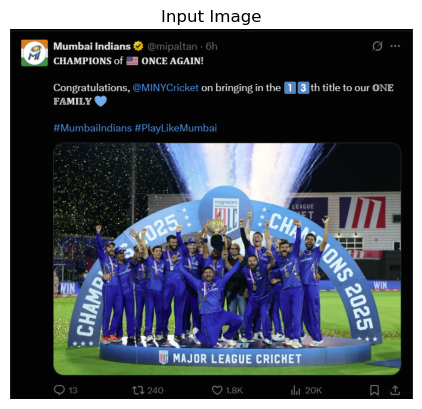

🔍 Image Summary: mumbai v mumbai tweet tweet tweet tweet tweet twee


In [13]:
def summarize_image(image_path):
    # Load image from local path
    image = Image.open(image_path).convert("RGB")
    
    # Display image
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()
    
    # Generate caption
    inputs = processor(image, return_tensors="pt")
    out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    
    print("🔍 Image Summary:", caption)
    return caption

# 🔍 Provide your image path here
image_path = "C:\\Users\\91722\\Desktop\\SPJIMR Mumbai\\My Courses\\Text_Image_Video Analytics using AI\\PPTs\\Session 6\\Images\\MI_Tweet_1.png"  # <- Change this to your actual image path
summary = summarize_image(image_path)

In [15]:
# Takeaway
# BLIP isn't OCR-aware: The BLIP model is designed to generate natural captions based on visual features (like a person, animal, or setting), 
# but it doesn’t perform full Optical Character Recognition (OCR). So, when the scene is text-heavy, it breaks down.

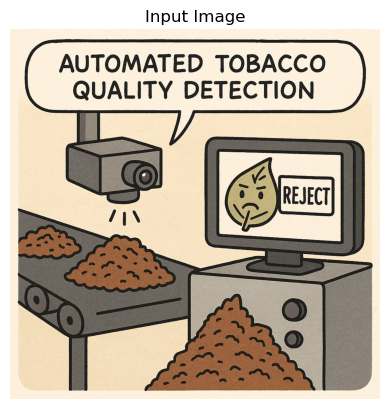

🔍 Image Summary: a cartoon of a robot that is watching a bowl of food


In [17]:
# 🔍 Provide your image path here
image_path = "C:\\Users\\91722\\Desktop\\SPJIMR Mumbai\\My Courses\\Text_Image_Video Analytics using AI\\PPTs\\Session 6\\Images\\Example to Try.png"
summary = summarize_image(image_path)

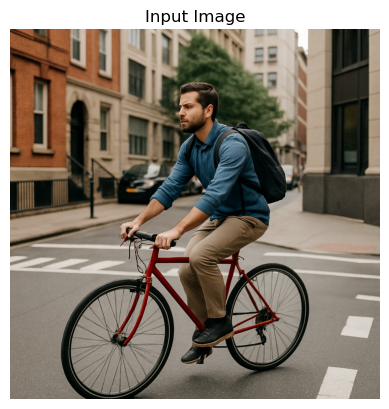

🔍 Image Summary: a man riding a bike down a street


In [19]:
# 🔍 Provide your image path here
image_path = "C:\\Users\\91722\\Desktop\\SPJIMR Mumbai\\My Courses\\Text_Image_Video Analytics using AI\\PPTs\\Session 6\\Images\\No Text Image.png"
summary = summarize_image(image_path)

In [21]:
import sys
!{sys.executable} -m pip install pytesseract

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [31]:
import pytesseract
# Set Tesseract path
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [33]:
# Load BLIP model and processor
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

def analyze_image(image_path):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Show image
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()

    # Extract text using OCR
    extracted_text = pytesseract.image_to_string(image)

    # Generate visual caption using BLIP
    inputs = processor(image, return_tensors="pt")
    output = model.generate(**inputs)
    visual_caption = processor.decode(output[0], skip_special_tokens=True)

    # Print results
    print("\n🔍 Visual Summary (BLIP):")
    print(visual_caption)

    print("\n📝 Text Extracted (OCR):")
    print(extracted_text.strip())

In [29]:
# If the code doesn't work
# Download Tesseract from here: https://github.com/UB-Mannheim/tesseract/wiki

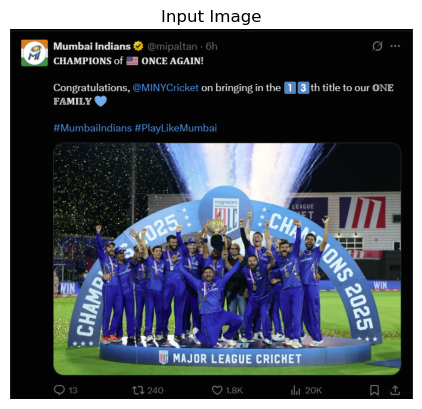


🔍 Visual Summary (BLIP):
mumbai v mumbai tweet tweet tweet tweet tweet twee

📝 Text Extracted (OCR):
Mumbai Indians % @mipaltan - 6h OD --

QF cHAMPIONS of 2S ONCE AGAIN!

Congratulations, on bringing in the {ij th title to our ONE
FAMILY @

On TQ 240 018k tht 20K As


In [35]:
# Provide your image path
image_path = "C:\\Users\\91722\\Desktop\\SPJIMR Mumbai\\My Courses\\Text_Image_Video Analytics using AI\\PPTs\\Session 6\\Images\\MI_Tweet_1.png" 
analyze_image(image_path)

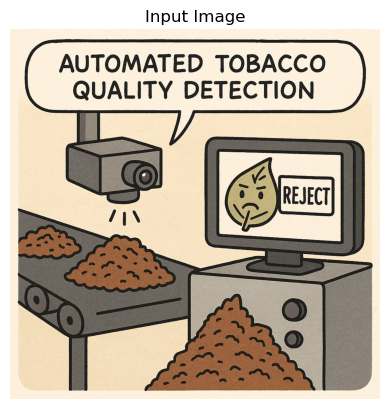


🔍 Visual Summary (BLIP):
a cartoon of a robot that is watching a bowl of food

📝 Text Extracted (OCR):
AUTOMATED TOBACCO
QUALITY DETECTION


In [37]:
# 🔍 Provide your image path here
image_path = "C:\\Users\\91722\\Desktop\\SPJIMR Mumbai\\My Courses\\Text_Image_Video Analytics using AI\\PPTs\\Session 6\\Images\\Example to Try.png"
analyze_image(image_path)

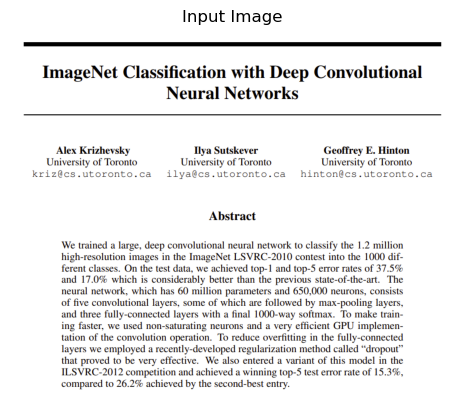


🔍 Visual Summary (BLIP):
a page from the article about the impact of the nuclear nuclear

📝 Text Extracted (OCR):
ImageNet Classification with Deep Convolutional
Neural Networks

Alex Krizhevsky Ilya Sutskever Geoffrey E. Hinton
University of Toronto University of Toronto University of Toronto
kriz@cs.utoronto.ca ilya@cs.utoronto.ca hinton@cs.utoronto.ca

Abstract

We trained a large, deep convolutional neural network to classify the 1.2 million
high-resolution images in the ImageNet LSVRC-2010 contest into the 1000 dif-
ferent classes. On the test data, we achieved top-1 and top-5 error rates of 37.5%
and 17.0% which is considerably better than the previous state-of-the-art. The
neural network, which has 60 million parameters and 650,000 neurons, consists
of five convolutional layers, some of which are followed by max-pooling layers,
and three fully-connected layers with a final 1000-way softmax. To make train-
ing faster, we used non-saturating neurons and a very efficient GPU imple

In [39]:
# 🔍 Provide your image path here
image_path = "C:\\Users\\91722\\Desktop\\SPJIMR Mumbai\\My Courses\\Text_Image_Video Analytics using AI\\PPTs\\Session 6\\Images\\AlexNet Paper.png"
analyze_image(image_path)

In [41]:
# ---------------------------Key Takeaways-------------------------------------------
# 1) Image Data Has Multiple Layers: 
#    Visual content (objects, scenes, actions) and embedded text (headlines, tweets, signage) are both critical in business images.

# 2) BLIP (Visual Captioning) Works Best for Natural Images
# Performs well on images with:
#          -> Clean backgrounds
#          -> Recognizable objects (people, bicycles, food, etc.)
#          -> Simple visual relationships

# Fails on:
#           -> Text-heavy or graphic-based images (e.g., tweets, posters)
#           -> Mixed content with emojis, overlays, or brand elements

# 3) OCR (Tesseract) Extracts Embedded Text
# Works well on:
#          -> Documents, PDFs, typed abstracts
#          -> High-contrast, clean fonts

# Struggles with:
#          -> Low-resolution images
#          -> Emojis, stylized fonts, or overlapping design elements

# 4) Hybrid Models = Smarter Image Understanding
# Neither BLIP nor OCR alone could fully summarize the tweet image.
# Combining both gives a richer, multi-layered summary:
#                  -> BLIP → scene description ("group of people celebrating")
#                  -> OCR → textual message ("CHAMPIONS of 2025", team name)